<div align="center" style="
    background: linear-gradient(135deg, #667eea, #764ba2);
    padding:35px;
    border-radius:15px;
    box-shadow:0 8px 25px rgba(0,0,0,0.25);
">
  <h1 style="
      color:white;
      font-family: 'Segoe UI', sans-serif;
      margin:0;
      font-size:42px;
      letter-spacing:1px;
  ">
     Customer Churn Predication by Prince Kumar 
  </h1>
</div>

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("F:\Churn_Modelling.csv")

In [3]:
df.shape

(10000, 14)

In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df.duplicated().sum()

0

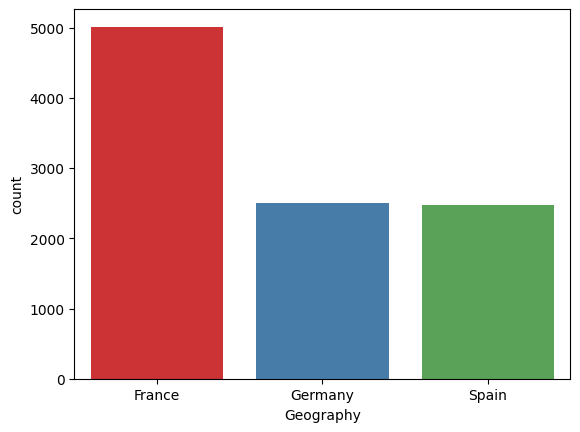

In [8]:
sns.barplot(df['Geography'].value_counts(),palette='Set1');

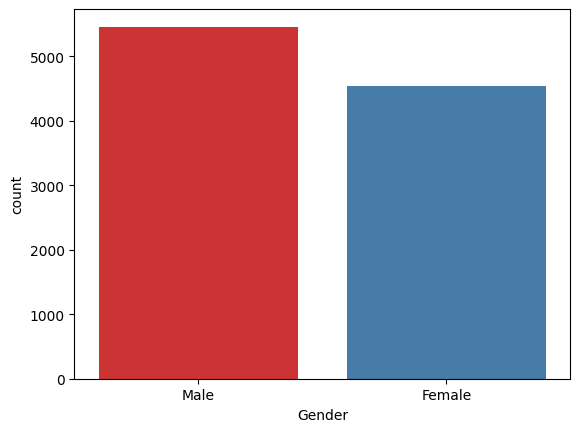

In [9]:
sns.barplot(df['Gender'].value_counts(),palette='Set1');

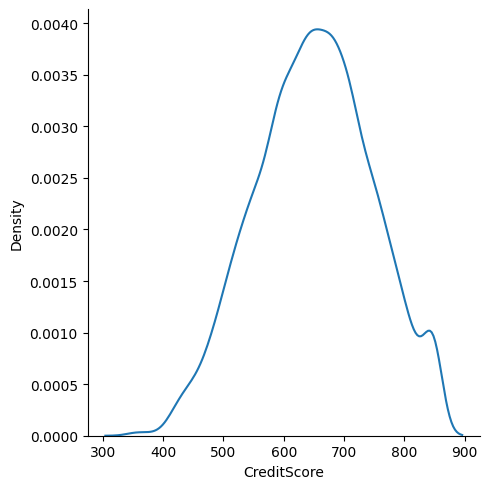

In [10]:
sns.displot(df['CreditScore'],kind='kde')

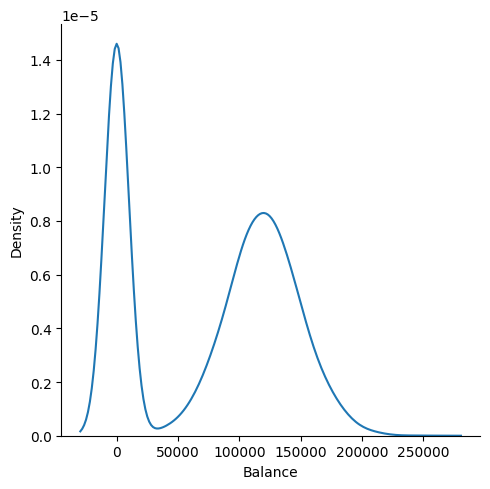

In [11]:
sns.displot(df['Balance'],kind='kde')

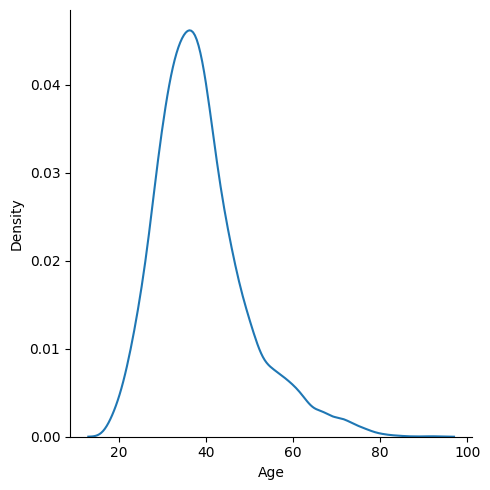

In [12]:
sns.displot(df['Age'],kind='kde')

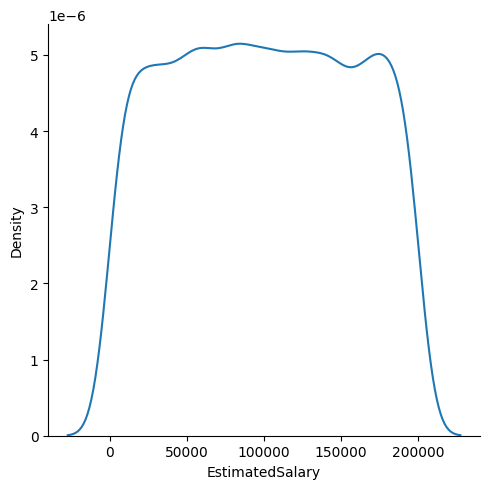

In [13]:
sns.displot(df['EstimatedSalary'],kind='kde')

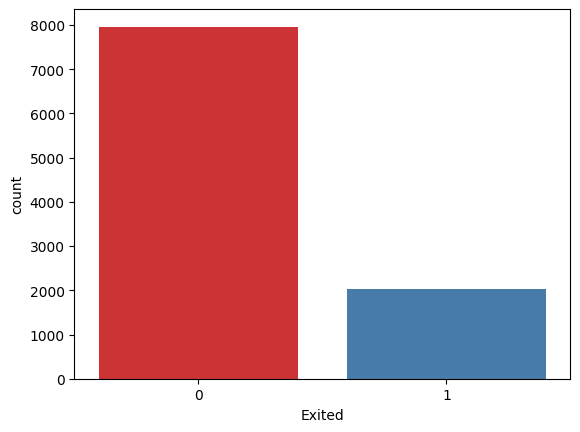

In [14]:
sns.barplot(df['Exited'].value_counts(),palette='Set1');

In [15]:
df['Tenure'].unique()

array([ 2,  1,  8,  7,  4,  6,  3, 10,  5,  9,  0], dtype=int64)

<Axes: xlabel='Tenure', ylabel='count'>

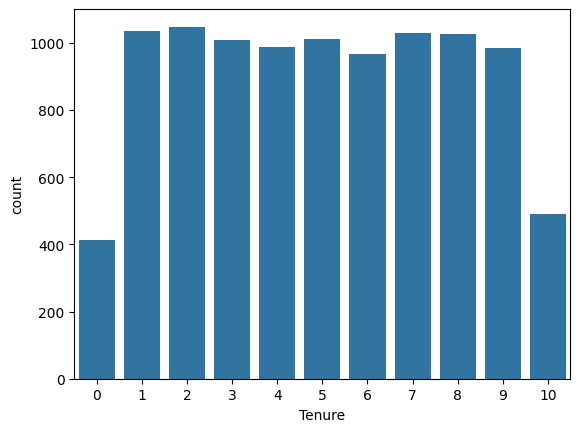

In [16]:
sns.barplot(df['Tenure'].value_counts())

In [17]:
X = df.iloc[:,3:-1]

In [18]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [19]:
y = df.iloc[:,-1]

In [20]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [21]:
X = pd.get_dummies(X,columns=['Geography','Gender'],drop_first=True)

In [22]:
X.shape

(10000, 11)

In [23]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


In [24]:
ss = StandardScaler()

In [25]:
x_scaled = ss.fit_transform(X)

In [26]:
x_scaled.shape

(10000, 11)

In [27]:
x_train_scaled , x_test_scaled , y_train_scaled , y_test_scaled = train_test_split(x_scaled, y,test_size=0.1,random_state=42)

In [28]:
x_train , x_test , y_train, y_test = train_test_split(X, y,test_size=0.1,random_state=42)

In [29]:
x_train.shape

(9000, 11)

In [30]:
y_train.shape

(9000,)

# Model Selection

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import accuracy_score



In [32]:
model_dict_scaled = {
             'SVM':SVC(),
             'Logistic_Reg': LogisticRegression(),}

In [33]:
model_dict = {'Naive_bayes':BernoulliNB(),
             'Decison_tree': DecisionTreeClassifier(),
             'Random_forest': RandomForestClassifier(),
             'Extra_tree': ExtraTreesClassifier(),
             'Gradient_Boosting':GradientBoostingClassifier(),
             'Ada_Boost': AdaBoostClassifier(),
             'XG_Boost':XGBClassifier(),
             'Light_gbm':LGBMClassifier(verbose=0),
             'Cat_Boost':CatBoostClassifier(verbose=0)}

In [34]:
model_output = []

for model_name,model in model_dict_scaled.items():
    print(f"{model_name} : {model}")
    model.fit(x_train_scaled,y_train_scaled)
    y_pred = model.predict(x_test_scaled)
    model_output.append(accuracy_score(y_test_scaled, y_pred))
    

SVM : SVC()
Logistic_Reg : LogisticRegression()


In [35]:
model_output

[0.864, 0.809]

In [40]:
model_output_scaled = []

for model_name,model in model_dict.items():
    print(f"{model_name} : {model}")
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    model_output_scaled.append(accuracy_score(y_test, y_pred))
    model_output_scaled.append(model_name)
    
    

Naive_bayes : BernoulliNB()
Decison_tree : DecisionTreeClassifier()
Random_forest : RandomForestClassifier()
Extra_tree : ExtraTreesClassifier()
Gradient_Boosting : GradientBoostingClassifier()
Ada_Boost : AdaBoostClassifier()
XG_Boost : XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)
L

In [41]:
model_output_scaled

[0.805,
 'Naive_bayes',
 0.794,
 'Decison_tree',
 0.87,
 'Random_forest',
 0.867,
 'Extra_tree',
 0.867,
 'Gradient_Boosting',
 0.855,
 'Ada_Boost',
 0.866,
 'XG_Boost',
 0.861,
 'Light_gbm',
 0.869,
 'Cat_Boost']

# Hyper Parameter Tuning for Random forest

In [46]:
from sklearn.model_selection import RandomizedSearchCV

In [47]:
from scipy.stats import randint

param_dist = {
    "n_estimators": randint(100, 500),          # more range
    "max_depth": [None] + list(range(5, 25)),   # allow deeper trees
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 20),
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False],
    "criterion": ["gini", "entropy", "log_loss"] 
}

In [48]:
RF = RandomForestClassifier()

In [50]:
tuner = RandomizedSearchCV(estimator=RF,cv=5,random_state=42,scoring='accuracy',param_distributions=param_dist,n_iter=50,n_jobs=-1)

In [51]:
tuner.fit(x_train,y_train)

,estimator,RandomForestClassifier()
,param_distributions,"{'bootstrap': [True, False], 'criterion': ['gini', 'entropy', ...], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], ...}"
,n_iter,50
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [52]:
tuner.best_score_

0.8648888888888889

In [57]:
best = tuner.best_params_
best

{'bootstrap': True,
 'criterion': 'log_loss',
 'max_depth': 23,
 'max_features': 'log2',
 'min_samples_leaf': 1,
 'min_samples_split': 12,
 'n_estimators': 212}

In [58]:
random = RandomForestClassifier(**best)

In [59]:
random.fit(x_train,y_train)

,n_estimators,212
,criterion,'log_loss'
,max_depth,23
,min_samples_split,12
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [60]:
y_pred_test = random.predict(x_test)

In [61]:
y_pred_train = random.predict(x_train)

In [62]:
accuracy_score(y_pred_test,y_test)

0.871

In [63]:
accuracy_score(y_pred_train,y_train)

0.9251111111111111

In [ ]:
# so here our model is Overfitting a little bit but we can improve it further.